**basic configuration**

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
import os
print(os.getcwd())

e:\student-performance-pridictor\notebooks


In [75]:
df = pd.read_csv('../data/student-mat.csv')

In [76]:
df.head()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [77]:
# rows and columns
df.shape

(395, 33)

no. of rows=395
no. of columns=33

In [78]:
# checking missing values
df.isnull().sum().sum()

0

there is no missing value in any column

In [79]:
#finding categorical columns
cat_cols = df.select_dtypes(include=['object','category']).columns
cat_cols

Index(['school', 'sex', 'address', 'famsize', 'Parrent_status', 'Mother_job',
       'Father_job', 'reason_to_chose_school', 'guardian', 'extra_edu_supp',
       'family_edu_supp', 'extra_paid_class', 'extra_curr_activities',
       'nursery', 'Interested_in_higher_edu', 'internet_access',
       'romantic_relationship'],
      dtype='object')

In [80]:
#unique value in each categorical columns
for col in cat_cols:
    print(f'\n{col} ({df[col].nunique()} unique values):')
    print(f'  {df[col].unique().tolist()}')


school (2 unique values):
  ['GP', 'MS']

sex (2 unique values):
  ['F', 'M']

address (2 unique values):
  ['U', 'R']

famsize (2 unique values):
  ['GT3', 'LE3']

Parrent_status (2 unique values):
  ['A', 'T']

Mother_job (5 unique values):
  ['at_home', 'health', 'other', 'services', 'teacher']

Father_job (5 unique values):
  ['teacher', 'other', 'services', 'health', 'at_home']

reason_to_chose_school (4 unique values):
  ['course', 'other', 'home', 'reputation']

guardian (3 unique values):
  ['mother', 'father', 'other']

extra_edu_supp (2 unique values):
  ['yes', 'no']

family_edu_supp (2 unique values):
  ['no', 'yes']

extra_paid_class (2 unique values):
  ['no', 'yes']

extra_curr_activities (2 unique values):
  ['no', 'yes']

nursery (2 unique values):
  ['yes', 'no']

Interested_in_higher_edu (2 unique values):
  ['yes', 'no']

internet_access (2 unique values):
  ['no', 'yes']

romantic_relationship (2 unique values):
  ['no', 'yes']


In [81]:
df.describe()

,age,Mother_edu,Father_edu,traveltime,weekly_studytime,failures,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   school                    395 non-null    object
 1   sex                       395 non-null    object
 2   age                       395 non-null    int64 
 3   address                   395 non-null    object
 4   famsize                   395 non-null    object
 5   Parrent_status            395 non-null    object
 6   Mother_edu                395 non-null    int64 
 7   Father_edu                395 non-null    int64 
 8   Mother_job                395 non-null    object
 9   Father_job                395 non-null    object
 10  reason_to_chose_school    395 non-null    object
 11  guardian                  395 non-null    object
 12  traveltime                395 non-null    int64 
 13  weekly_studytime          395 non-null    int64 
 14  failures                  

**Data Cleaning**

In [83]:
#duplicates
df.duplicated().sum()

0

In [84]:
#missing values
df.isnull().sum().sum()

0

In [85]:
# identify a binary yes/no column
binary_cols=[]
cat_cols=df.select_dtypes(include=['object','category']).columns
cat_cols

Index(['school', 'sex', 'address', 'famsize', 'Parrent_status', 'Mother_job',
       'Father_job', 'reason_to_chose_school', 'guardian', 'extra_edu_supp',
       'family_edu_supp', 'extra_paid_class', 'extra_curr_activities',
       'nursery', 'Interested_in_higher_edu', 'internet_access',
       'romantic_relationship'],
      dtype='object')

In [86]:
for col in cat_cols:
    # Strip whitespace and lowercase for comparison
    unique_vals = df[col].str.strip().str.lower().unique()
    if set(unique_vals).issubset({'yes', 'no'}):
        binary_cols.append(col)

In [87]:
binary_cols

['extra_edu_supp',
 'family_edu_supp',
 'extra_paid_class',
 'extra_curr_activities',
 'nursery',
 'Interested_in_higher_edu',
 'internet_access',
 'romantic_relationship']

In [88]:
#convert yes/no to 0/1
for col in binary_cols:
    df[col] = df[col].str.strip().str.lower().map({'yes': 1, 'no': 0})

In [89]:
df[['romantic_relationship','extra_edu_supp','family_edu_supp','extra_paid_class','extra_curr_activities','nursery','Interested_in_higher_edu','internet_access','romantic_relationship']]

,romantic_relationship,extra_edu_supp,family_edu_supp,extra_paid_class,extra_curr_activities,nursery,Interested_in_higher_edu,internet_access,romantic_relationship
0,0,1,0,0,0,1,1,0,0
1,0,0,1,0,0,0,1,1,0
2,0,1,0,1,0,1,1,1,0
3,1,0,1,1,1,1,1,1,1
4,0,0,1,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...
390,0,0,1,1,0,1,1,0,0
391,0,0,0,0,0,0,1,1,0
392,0,0,0,0,0,0,1,0,0
393,0,0,0,0,0,0,1,1,0


In [90]:
df.dtypes

school                      object
sex                         object
age                          int64
address                     object
famsize                     object
Parrent_status              object
Mother_edu                   int64
Father_edu                   int64
Mother_job                  object
Father_job                  object
reason_to_chose_school      object
guardian                    object
traveltime                   int64
weekly_studytime             int64
failures                     int64
extra_edu_supp               int64
family_edu_supp              int64
extra_paid_class             int64
extra_curr_activities        int64
nursery                      int64
Interested_in_higher_edu     int64
internet_access              int64
romantic_relationship        int64
Family_quality_reln          int64
freetime_after_school        int64
goout_with_friends           int64
workday_alcohol_consum       int64
weekend_alcohol_consum       int64
health_status       

In [91]:
# Standardize remaining categorical columns (strip whitespace, lowercase)
remaining_cat_cols = df.select_dtypes(include=['object']).columns
remaining_cat_cols

Index(['school', 'sex', 'address', 'famsize', 'Parrent_status', 'Mother_job',
       'Father_job', 'reason_to_chose_school', 'guardian'],
      dtype='object')

In [92]:
for col in remaining_cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [93]:
# outliers columns
# i will target absences, studytime, failures as these features will influence the final output
outlier_cols = ['absences']
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
     # Cap outliers (winsorization)
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    
    print(f'\n{col}:')
    print(f'  Q1={Q1}, Q3={Q3}, IQR={IQR}')
    print(f'  Bounds: [{lower_bound}, {upper_bound}]')
    print(f'  Outliers capped: {outliers_before}')


absences:
  Q1=0.0, Q3=8.0, IQR=8.0
  Bounds: [-12.0, 20.0]
  Outliers capped: 15


In [94]:
outliers_after = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

In [95]:
outliers_after

0

**Feature Engineering**

In [96]:
# Average score from period 1 and period 2 grades
df['avg_score'] = (df['G1'] + df['G2']) / 2

In [97]:
# Grade trend: improvement or decline from G1 to G2 posive=improving negative=declining
df['grade_trend'] = df['G2'] - df['G1']

In [98]:
# Total score across all periods
df['total_score'] = df['G1'] + df['G2'] + df['G3']

In [99]:
# Family education level (combined parents education)
df['family_edu'] = df['Mother_edu'] + df['Father_edu']

In [100]:
df['family_edu']

0      8
1      2
2      2
3      6
4      6
      ..
390    4
391    4
392    2
393    5
394    2
Name: family_edu, Length: 395, dtype: int64

In [101]:
# Total alcohol consumption (workday + weekend)
df['total_alcohol'] = df['workday_alcohol_consum'] + df['weekend_alcohol_consum']

In [102]:
df.shape

(395, 38)

In [103]:
# High absence flag (above 75th percentile)
absence_threshold = df['absences'].quantile(0.75)
df['high_absence'] = (df['absences'] > absence_threshold).astype(int)

In [104]:
absence_threshold

8.0

In [105]:
df['high_absence']

0      0
1      0
2      1
3      0
4      0
      ..
390    1
391    0
392    0
393    0
394    0
Name: high_absence, Length: 395, dtype: int32

In [106]:
# High alcohol flag (total_alcohol above median)
alcohol_threshold = df['total_alcohol'].median()
alcohol_threshold

3.0

In [107]:
df['high_alcohol'] = (df['total_alcohol'] > alcohol_threshold).astype(int)

In [108]:
df['high_alcohol']

0      0
1      0
2      1
3      0
4      0
      ..
390    1
391    1
392    1
393    1
394    1
Name: high_alcohol, Length: 395, dtype: int32

In [109]:
df.shape

(395, 40)

In [110]:
df['failures'].nunique()

4

In [111]:
cln_df=df.copy()

**Encoding Categorical values**

In [112]:
cat_cols = cln_df.select_dtypes(include=['object']).columns.tolist()
cat_cols

['school',
 'sex',
 'address',
 'famsize',
 'Parrent_status',
 'Mother_job',
 'Father_job',
 'reason_to_chose_school',
 'guardian']

In [113]:
print(f'Remaining categorical columns ({len(cat_cols)}):')

Remaining categorical columns (9):


In [114]:
for col in cat_cols:
    print(f'  {col}: {cln_df[col].nunique()} unique → {cln_df[col].unique().tolist()}')

  school: 2 unique → ['gp', 'ms']
  sex: 2 unique → ['f', 'm']
  address: 2 unique → ['u', 'r']
  famsize: 2 unique → ['gt3', 'le3']
  Parrent_status: 2 unique → ['a', 't']
  Mother_job: 5 unique → ['at_home', 'health', 'other', 'services', 'teacher']
  Father_job: 5 unique → ['teacher', 'other', 'services', 'health', 'at_home']
  reason_to_chose_school: 4 unique → ['course', 'other', 'home', 'reputation']
  guardian: 3 unique → ['mother', 'father', 'other']


In [115]:
# Identify binary categorical columns (2 unique values)
binary_cat_cols = [col for col in cat_cols if cln_df[col].nunique() == 2]
binary_cat_cols

['school', 'sex', 'address', 'famsize', 'Parrent_status']

label encoding for binary categorical columns

In [116]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in binary_cat_cols:
    original_values = cln_df[col].unique().tolist()
    cln_df[col] = le.fit_transform(cln_df[col])
    encoded_values = cln_df[col].unique().tolist()
    print(f'  {col}: {original_values} → {encoded_values}')

  school: ['gp', 'ms'] → [0, 1]
  sex: ['f', 'm'] → [0, 1]
  address: ['u', 'r'] → [1, 0]
  famsize: ['gt3', 'le3'] → [0, 1]
  Parrent_status: ['a', 't'] → [0, 1]


multi catigorical columns

In [117]:
multi_cat_cols = [col for col in cat_cols if cln_df[col].nunique() > 2]

In [118]:
multi_cat_cols

['Mother_job', 'Father_job', 'reason_to_chose_school', 'guardian']

In [119]:
for col in multi_cat_cols:
    print(f'  {col}: {cln_df[col].nunique()} categories → {cln_df[col].unique().tolist()}')

  Mother_job: 5 categories → ['at_home', 'health', 'other', 'services', 'teacher']
  Father_job: 5 categories → ['teacher', 'other', 'services', 'health', 'at_home']
  reason_to_chose_school: 4 categories → ['course', 'other', 'home', 'reputation']
  guardian: 3 categories → ['mother', 'father', 'other']


In [120]:
cln_df = pd.get_dummies(cln_df, columns=multi_cat_cols, drop_first=True, dtype=int)

In [121]:
cln_df.head()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,traveltime,weekly_studytime,...,Mother_job_teacher,Father_job_health,Father_job_other,Father_job_services,Father_job_teacher,reason_to_chose_school_home,reason_to_chose_school_other,reason_to_chose_school_reputation,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,1,0,1,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,1,1,1,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0
3,0,0,15,1,0,1,4,2,1,3,...,0,0,0,1,0,1,0,0,1,0
4,0,0,16,1,0,1,3,3,1,2,...,0,0,1,0,0,1,0,0,0,0


In [122]:
cln_df.shape

(395, 49)

In [123]:
df.shape

(395, 40)

Exploratory Data Analysis

In [ ]:
# Calculate correlations with G3
correlations = cln_df.corr()['G3'].sort_values(ascending=False)
correlations

G3                                   1.000000
total_score                          0.959873
G2                                   0.904868
avg_score                            0.889792
G1                                   0.801468
grade_trend                          0.377020
Mother_edu                           0.217147
family_edu                           0.205224
Interested_in_higher_edu             0.182465
Father_edu                           0.152457
Mother_job_health                    0.116158
address                              0.105756
sex                                  0.103456
extra_paid_class                     0.101996
internet_access                      0.098483
weekly_studytime                     0.097820
reason_to_chose_school_reputation    0.095692
Father_job_teacher                   0.095374
famsize                              0.081407
Mother_job_services                  0.078429
absences                             0.068030
Mother_job_teacher                

In [125]:
# Plot heatmap for top correlations
top_features = correlations.abs().sort_values(ascending=False).index[:15]
top_features

Index(['G3', 'total_score', 'G2', 'avg_score', 'G1', 'grade_trend', 'failures',
       'Mother_edu', 'family_edu', 'Interested_in_higher_edu', 'age',
       'Father_edu', 'goout_with_friends', 'romantic_relationship',
       'traveltime'],
      dtype='object')

In [126]:

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

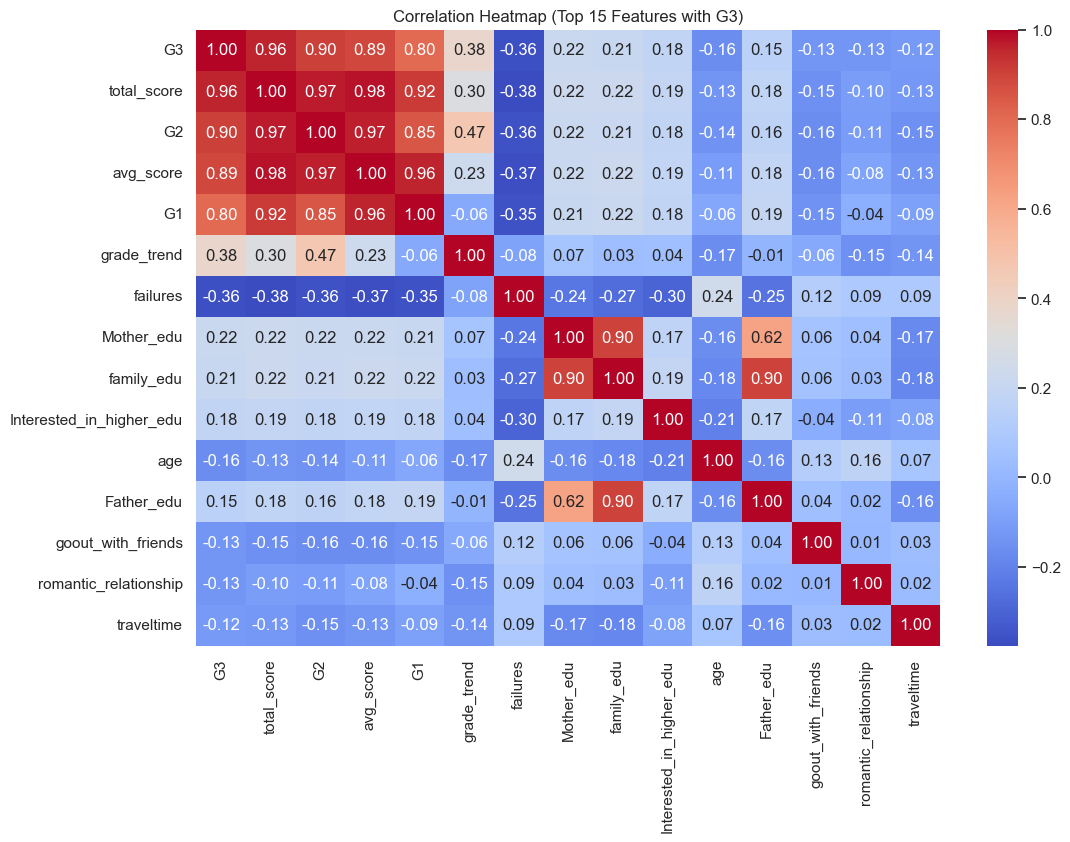

In [127]:
sns.heatmap(cln_df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top 15 Features with G3)')
plt.show()

Scatter plot--> Visualizing relationship between intermediate grades and final grade

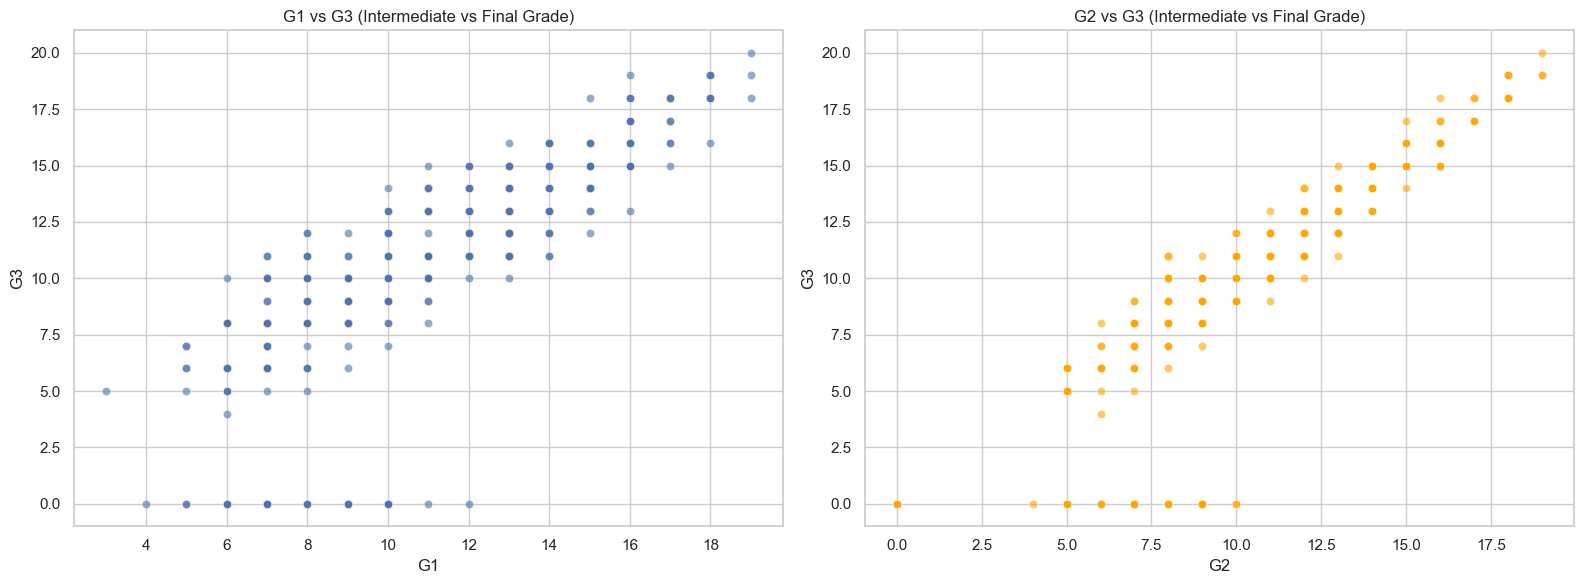

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='G1', y='G3', ax=axes[0], alpha=0.6)
axes[0].set_title('G1 vs G3 (Intermediate vs Final Grade)')

sns.scatterplot(data=df, x='G2', y='G3', ax=axes[1], alpha=0.6, color='orange')
axes[1].set_title('G2 vs G3 (Intermediate vs Final Grade)')

plt.tight_layout()
plt.show()

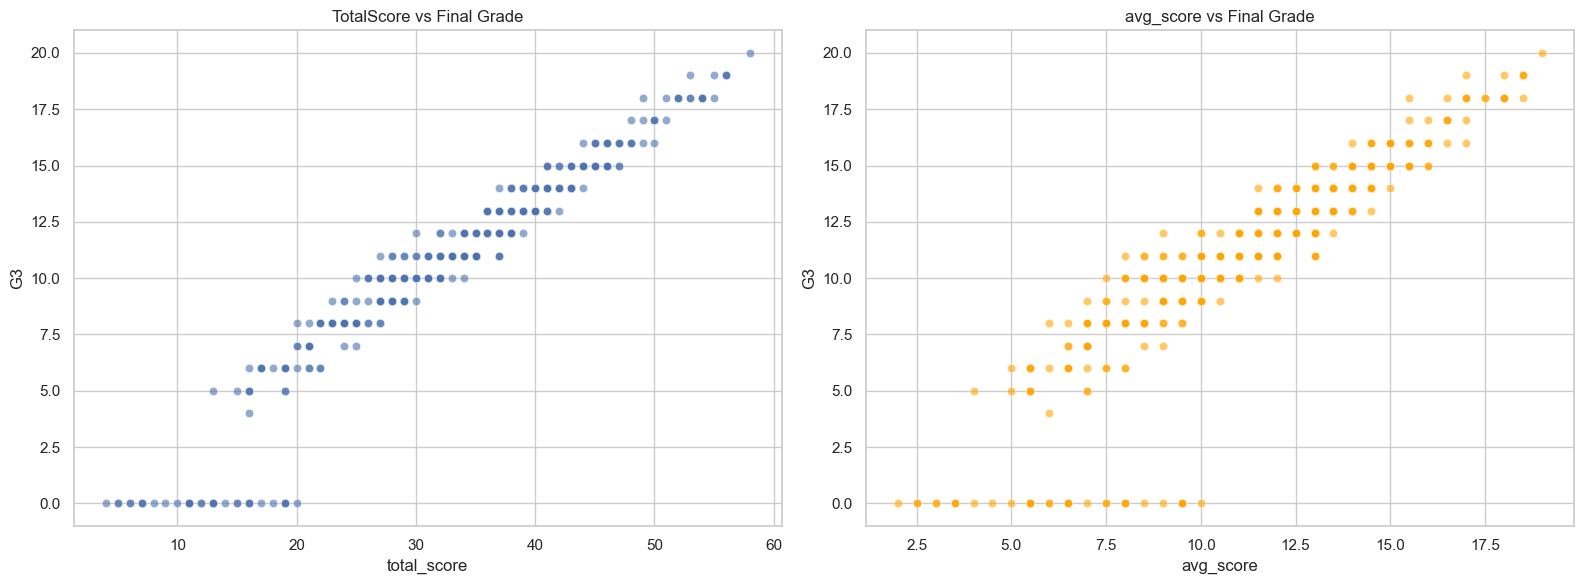

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='total_score', y='G3', ax=axes[0], alpha=0.6)
axes[0].set_title('TotalScore vs Final Grade')

sns.scatterplot(data=df, x='avg_score', y='G3', ax=axes[1], alpha=0.6, color='orange')
axes[1].set_title('avg_score vs Final Grade')

plt.tight_layout()
plt.show()

Bar Charts--Visualizing average G3 across key categorical/encoded features

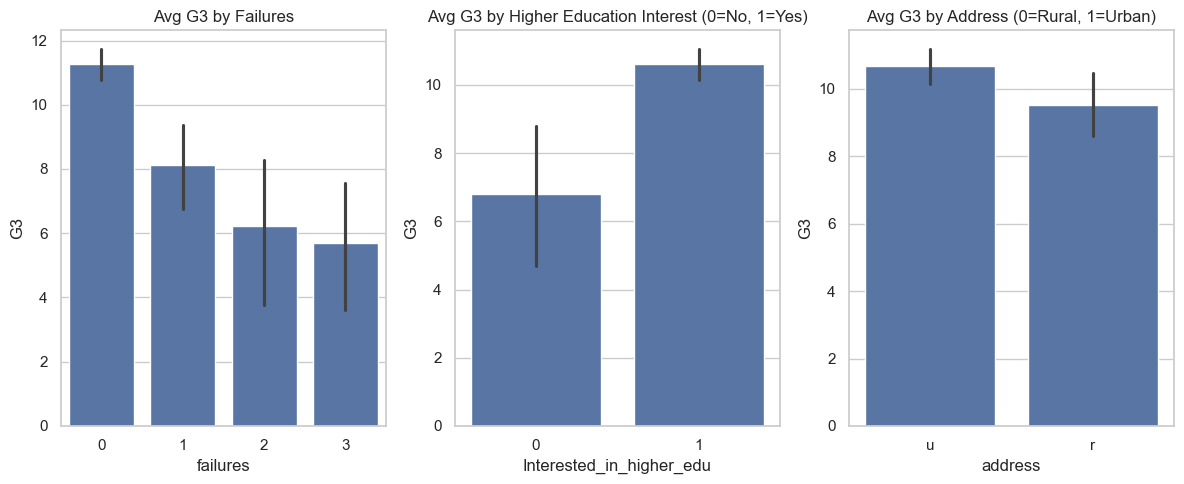

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Average G3 by Failures
sns.barplot(data=df, x='failures', y='G3', ax=axes[0])
axes[0].set_title('Avg G3 by Failures')

# Average G3 by Higher Education Desire
sns.barplot(data=df, x='Interested_in_higher_edu', y='G3', ax=axes[1])
axes[1].set_title('Avg G3 by Higher Education Interest (0=No, 1=Yes)')

# Average G3 by Address
sns.barplot(data=df, x='address', y='G3', ax=axes[2])
axes[2].set_title('Avg G3 by Address (0=Rural, 1=Urban)')

plt.tight_layout()
plt.show()

In [132]:
cln_df[['G1','G2','G3']]

,G1,G2,G3
0,5,6,6
1,5,5,6
2,7,8,10
3,15,14,15
4,6,10,10
...,...,...,...
390,9,9,9
391,14,16,16
392,10,8,7
393,11,12,10


**Feature Selection**

Drop Low Correlation Features
Identifying features with absolute correlation to **G3** below **0.05** (Target **G3** is protected)

In [134]:
corr_threshold = 0.05
abs_corrs = cln_df.corr()['G3'].abs().sort_values()
low_corr_features = [f for f in abs_corrs[abs_corrs < corr_threshold].index if f != 'G3']


In [135]:
low_corr_features

['high_absence',
 'freetime_after_school',
 'extra_curr_activities',
 'Father_job_services',
 'reason_to_chose_school_home',
 'guardian_mother',
 'family_edu_supp',
 'school']

In [136]:
cln_df.shape

(395, 49)

In [137]:
# Drop features
cln_df.drop(columns=low_corr_features, inplace=True)

In [138]:
cln_df.shape

(395, 41)

Drop Highly Redundant Features (Multicollinearity)
Identifying pairs of features with correlation above **0.9** and dropping one (Target **G3** is protected)

In [141]:
redundancy_threshold = 0.9
corr_matrix = cln_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > redundancy_threshold) and column != 'G3']

In [142]:
to_drop

['avg_score', 'total_score', 'family_edu', 'total_alcohol']

In [143]:
cln_df.shape

(395, 41)

In [144]:
cln_df.drop(columns=to_drop, inplace=True)

In [145]:
cln_df.shape

(395, 37)

In [147]:
cln_df.to_csv('../data/cleaned_student_data.csv', index=False)